## Importing Libraries

In [22]:
###########################
## Import Torch Libaries
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
###########################
## Import standard libaries
import pandas as pd
import numpy as np
import os
import random
##########################
## Import PIL
from PIL import Image

#####################
## import SK learn libaries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
####################
## import matplot
import matplotlib.pyplot as plt


In [23]:
#####################
##Enable CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Figuring out the dimension of the images

In [24]:
#################################
folder_path = './Images'

# Define a transform without resizing (to maintain original dimensions)
transform = transforms.Compose([transforms.ToTensor()])

# Create an ImageFolder dataset
dataset = ImageFolder(root=folder_path, transform=transform)

# Choose an index for the image you want to check
index_to_check = 0

# Retrieve the image and its dimensions
image, label = dataset[index_to_check]
original_dimensions = image.shape

# Print the original dimensions
print(f"Original dimensions of the image: {original_dimensions}")


Original dimensions of the image: torch.Size([3, 48, 48])


## Mapping labels with images

In [25]:
##########################################
class EmotionDetection(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.classes = os.listdir(data_path)
        ## make an array for images and labls
        self.images = []
        self.labels = []
        ## iterate through emotion class
        for i, emotion_class in enumerate(self.classes):
            ### grab all images in folders
            class_path = os.path.join(data_path, emotion_class)
            ## iterate image_name in path
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)
                self.images.append(image_path)
                self.labels.append(i)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label = self.labels[index]

        # Open the image
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Convert label to a single index
        label = torch.tensor(label, dtype=torch.long)

        return image, label




In [26]:
##############################
data_path = './Images'  
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
])

dataset = EmotionDetection(data_path=data_path, transform=transform)
##############################

In [27]:
##############################
index = 0
image, label = dataset[index]
##############################

In [28]:
##############################
image.shape
##############################

torch.Size([3, 48, 48])

In [29]:

## labell are based on the directory name
# which means 0 is the first folder name, 
#1 is the second folder name, etc.
label 


tensor(0)

## View Class

In [30]:
######################
## View Class
class View(nn.Module):
    
    def __init__(self, shape):
        
        super().__init__()
        self.shape = shape,

    def forward(self, x):
        return x.view(*self.shape)


## Model

In [31]:

class Classifier_CNN_3_Layers(nn.Module):
    def __init__(self):
        super(Classifier_CNN_3_Layers, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.pool1= nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 4)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool3(x)
        ## flatten and connect all layers
        x = x.view(-1, 256 * 6 * 6)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        # Softmax activation for multiclass classification
        return F.softmax(x, dim=1) 




## Splitting the dataset into training and testing


In [32]:

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])


## Creating dataloader

In [33]:
##############################
batch_size = 32

# Create DataLoader instances for training and testing datasets
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

##############################

## Run Model

In [34]:

%%time
cnn_classifier = Classifier_CNN_3_Layers().to(device)  
# Update the model accordingly

optimizer = optim.SGD(cnn_classifier.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss() 

epochs = 100

for epoch in range(epochs):
    # Training
    cnn_classifier.train()
    ## iterate through images in labels in train data loader
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        ### zero out gradients
        optimizer.zero_grad()
        outputs = cnn_classifier(images)
        
        # Uncomment or comment to control predicted prints
        # print("Predictions:", torch.argmax(outputs, dim=1))
        # print("True Labels:", labels)
        loss = criterion(outputs, labels)
        ## send update weights
        loss.backward()
        ## 
        optimizer.step()
        print(f"Epoch {epoch + 1}/{epochs}, Iteration {i + 1}/{len(train_loader)}, Loss: {loss.item()}")



Epoch 1/100, Iteration 1/38, Loss: 1.3849209547042847
Epoch 1/100, Iteration 2/38, Loss: 1.3821258544921875
Epoch 1/100, Iteration 3/38, Loss: 1.379744052886963
Epoch 1/100, Iteration 4/38, Loss: 1.37820303440094
Epoch 1/100, Iteration 5/38, Loss: 1.375844120979309
Epoch 1/100, Iteration 6/38, Loss: 1.3738727569580078
Epoch 1/100, Iteration 7/38, Loss: 1.3741204738616943
Epoch 1/100, Iteration 8/38, Loss: 1.3712738752365112
Epoch 1/100, Iteration 9/38, Loss: 1.3687533140182495
Epoch 1/100, Iteration 10/38, Loss: 1.3665953874588013
Epoch 1/100, Iteration 11/38, Loss: 1.3665266036987305
Epoch 1/100, Iteration 12/38, Loss: 1.3605526685714722
Epoch 1/100, Iteration 13/38, Loss: 1.3568280935287476
Epoch 1/100, Iteration 14/38, Loss: 1.366615891456604
Epoch 1/100, Iteration 15/38, Loss: 1.3522554636001587
Epoch 1/100, Iteration 16/38, Loss: 1.3537577390670776
Epoch 1/100, Iteration 17/38, Loss: 1.35163414478302
Epoch 1/100, Iteration 18/38, Loss: 1.3468477725982666
Epoch 1/100, Iteration 19/

Epoch 5/100, Iteration 1/38, Loss: 1.3090001344680786
Epoch 5/100, Iteration 2/38, Loss: 1.3202738761901855
Epoch 5/100, Iteration 3/38, Loss: 1.312889814376831
Epoch 5/100, Iteration 4/38, Loss: 1.3101656436920166
Epoch 5/100, Iteration 5/38, Loss: 1.3063477277755737
Epoch 5/100, Iteration 6/38, Loss: 1.2970587015151978
Epoch 5/100, Iteration 7/38, Loss: 1.287160873413086
Epoch 5/100, Iteration 8/38, Loss: 1.3358803987503052
Epoch 5/100, Iteration 9/38, Loss: 1.3040703535079956
Epoch 5/100, Iteration 10/38, Loss: 1.3496689796447754
Epoch 5/100, Iteration 11/38, Loss: 1.3130868673324585
Epoch 5/100, Iteration 12/38, Loss: 1.3139327764511108
Epoch 5/100, Iteration 13/38, Loss: 1.3112179040908813
Epoch 5/100, Iteration 14/38, Loss: 1.2952885627746582
Epoch 5/100, Iteration 15/38, Loss: 1.3186967372894287
Epoch 5/100, Iteration 16/38, Loss: 1.3226585388183594
Epoch 5/100, Iteration 17/38, Loss: 1.3114360570907593
Epoch 5/100, Iteration 18/38, Loss: 1.3236595392227173
Epoch 5/100, Iteratio

Epoch 9/100, Iteration 7/38, Loss: 1.2973440885543823
Epoch 9/100, Iteration 8/38, Loss: 1.3054550886154175
Epoch 9/100, Iteration 9/38, Loss: 1.2893372774124146
Epoch 9/100, Iteration 10/38, Loss: 1.3428775072097778
Epoch 9/100, Iteration 11/38, Loss: 1.3167628049850464
Epoch 9/100, Iteration 12/38, Loss: 1.307430386543274
Epoch 9/100, Iteration 13/38, Loss: 1.298807978630066
Epoch 9/100, Iteration 14/38, Loss: 1.3529434204101562
Epoch 9/100, Iteration 15/38, Loss: 1.3136253356933594
Epoch 9/100, Iteration 16/38, Loss: 1.2910540103912354
Epoch 9/100, Iteration 17/38, Loss: 1.321298599243164
Epoch 9/100, Iteration 18/38, Loss: 1.305814504623413
Epoch 9/100, Iteration 19/38, Loss: 1.314191460609436
Epoch 9/100, Iteration 20/38, Loss: 1.3000504970550537
Epoch 9/100, Iteration 21/38, Loss: 1.317578911781311
Epoch 9/100, Iteration 22/38, Loss: 1.298857569694519
Epoch 9/100, Iteration 23/38, Loss: 1.3105533123016357
Epoch 9/100, Iteration 24/38, Loss: 1.3095170259475708
Epoch 9/100, Iterati

Epoch 13/100, Iteration 11/38, Loss: 1.2950830459594727
Epoch 13/100, Iteration 12/38, Loss: 1.3590768575668335
Epoch 13/100, Iteration 13/38, Loss: 1.2907514572143555
Epoch 13/100, Iteration 14/38, Loss: 1.305885672569275
Epoch 13/100, Iteration 15/38, Loss: 1.3169703483581543
Epoch 13/100, Iteration 16/38, Loss: 1.288836121559143
Epoch 13/100, Iteration 17/38, Loss: 1.267128825187683
Epoch 13/100, Iteration 18/38, Loss: 1.2741862535476685
Epoch 13/100, Iteration 19/38, Loss: 1.2945760488510132
Epoch 13/100, Iteration 20/38, Loss: 1.2984182834625244
Epoch 13/100, Iteration 21/38, Loss: 1.3224886655807495
Epoch 13/100, Iteration 22/38, Loss: 1.3506569862365723
Epoch 13/100, Iteration 23/38, Loss: 1.310646653175354
Epoch 13/100, Iteration 24/38, Loss: 1.2991530895233154
Epoch 13/100, Iteration 25/38, Loss: 1.3088667392730713
Epoch 13/100, Iteration 26/38, Loss: 1.302046537399292
Epoch 13/100, Iteration 27/38, Loss: 1.2848180532455444
Epoch 13/100, Iteration 28/38, Loss: 1.32641410827636

Epoch 17/100, Iteration 10/38, Loss: 1.2478866577148438
Epoch 17/100, Iteration 11/38, Loss: 1.2703100442886353
Epoch 17/100, Iteration 12/38, Loss: 1.2554278373718262
Epoch 17/100, Iteration 13/38, Loss: 1.2928404808044434
Epoch 17/100, Iteration 14/38, Loss: 1.2524232864379883
Epoch 17/100, Iteration 15/38, Loss: 1.2686303853988647
Epoch 17/100, Iteration 16/38, Loss: 1.290482997894287
Epoch 17/100, Iteration 17/38, Loss: 1.3272823095321655
Epoch 17/100, Iteration 18/38, Loss: 1.2640681266784668
Epoch 17/100, Iteration 19/38, Loss: 1.2426934242248535
Epoch 17/100, Iteration 20/38, Loss: 1.2577576637268066
Epoch 17/100, Iteration 21/38, Loss: 1.337968111038208
Epoch 17/100, Iteration 22/38, Loss: 1.3066065311431885
Epoch 17/100, Iteration 23/38, Loss: 1.3124136924743652
Epoch 17/100, Iteration 24/38, Loss: 1.2933471202850342
Epoch 17/100, Iteration 25/38, Loss: 1.2728620767593384
Epoch 17/100, Iteration 26/38, Loss: 1.2718360424041748
Epoch 17/100, Iteration 27/38, Loss: 1.36736893653

...

Epoch 84/100, Iteration 30/38, Loss: 0.8072982430458069
Epoch 84/100, Iteration 31/38, Loss: 0.9004782438278198
Epoch 84/100, Iteration 32/38, Loss: 0.8701288104057312
Epoch 84/100, Iteration 33/38, Loss: 0.775547206401825
Epoch 84/100, Iteration 34/38, Loss: 0.8379886746406555
Epoch 84/100, Iteration 35/38, Loss: 0.8681514859199524
Epoch 84/100, Iteration 36/38, Loss: 0.7452865242958069
Epoch 84/100, Iteration 37/38, Loss: 0.8690897822380066
Epoch 84/100, Iteration 38/38, Loss: 0.992340087890625
Epoch 85/100, Iteration 1/38, Loss: 0.8381621837615967
Epoch 85/100, Iteration 2/38, Loss: 0.826164722442627
Epoch 85/100, Iteration 3/38, Loss: 0.9737062454223633
Epoch 85/100, Iteration 4/38, Loss: 0.8724133968353271
Epoch 85/100, Iteration 5/38, Loss: 0.8433629870414734
Epoch 85/100, Iteration 6/38, Loss: 0.9031310081481934
Epoch 85/100, Iteration 7/38, Loss: 0.9011381268501282
Epoch 85/100, Iteration 8/38, Loss: 0.9321011304855347
Epoch 85/100, Iteration 9/38, Loss: 0.8382111191749573
Epoc

Epoch 88/100, Iteration 31/38, Loss: 0.8994541764259338
Epoch 88/100, Iteration 32/38, Loss: 0.9603503942489624
Epoch 88/100, Iteration 33/38, Loss: 0.9603463411331177
Epoch 88/100, Iteration 34/38, Loss: 0.897161602973938
Epoch 88/100, Iteration 35/38, Loss: 0.867064893245697
Epoch 88/100, Iteration 36/38, Loss: 0.8961166739463806
Epoch 88/100, Iteration 37/38, Loss: 0.8414139151573181
Epoch 88/100, Iteration 38/38, Loss: 0.7444870471954346
Epoch 89/100, Iteration 1/38, Loss: 0.8358907103538513
Epoch 89/100, Iteration 2/38, Loss: 0.8045905828475952
Epoch 89/100, Iteration 3/38, Loss: 0.8938813805580139
Epoch 89/100, Iteration 4/38, Loss: 0.8053818345069885
Epoch 89/100, Iteration 5/38, Loss: 0.868754506111145
Epoch 89/100, Iteration 6/38, Loss: 0.9002546668052673
Epoch 89/100, Iteration 7/38, Loss: 0.8690401911735535
Epoch 89/100, Iteration 8/38, Loss: 0.9608261585235596
Epoch 89/100, Iteration 9/38, Loss: 0.9002617597579956
Epoch 89/100, Iteration 10/38, Loss: 0.8699653148651123
Epoc

Epoch 92/100, Iteration 33/38, Loss: 0.8379796743392944
Epoch 92/100, Iteration 34/38, Loss: 0.8980579972267151
Epoch 92/100, Iteration 35/38, Loss: 0.9011538028717041
Epoch 92/100, Iteration 36/38, Loss: 0.866945207118988
Epoch 92/100, Iteration 37/38, Loss: 0.9286676049232483
Epoch 92/100, Iteration 38/38, Loss: 0.9856787323951721
Epoch 93/100, Iteration 1/38, Loss: 0.8420169949531555
Epoch 93/100, Iteration 2/38, Loss: 0.8692736625671387
Epoch 93/100, Iteration 3/38, Loss: 0.7752121686935425
Epoch 93/100, Iteration 4/38, Loss: 0.8064178824424744
Epoch 93/100, Iteration 5/38, Loss: 0.8701651692390442
Epoch 93/100, Iteration 6/38, Loss: 0.9894812703132629
Epoch 93/100, Iteration 7/38, Loss: 0.7754240036010742
Epoch 93/100, Iteration 8/38, Loss: 0.8674070239067078
Epoch 93/100, Iteration 9/38, Loss: 0.9274565577507019
Epoch 93/100, Iteration 10/38, Loss: 0.8672526478767395
Epoch 93/100, Iteration 11/38, Loss: 0.8690581917762756
Epoch 93/100, Iteration 12/38, Loss: 0.8075091242790222
Ep

Epoch 96/100, Iteration 30/38, Loss: 0.8986355066299438
Epoch 96/100, Iteration 31/38, Loss: 0.9259089827537537
Epoch 96/100, Iteration 32/38, Loss: 1.0229518413543701
Epoch 96/100, Iteration 33/38, Loss: 0.926913321018219
Epoch 96/100, Iteration 34/38, Loss: 0.9005125164985657
Epoch 96/100, Iteration 35/38, Loss: 0.8064532279968262
Epoch 96/100, Iteration 36/38, Loss: 0.9291814565658569
Epoch 96/100, Iteration 37/38, Loss: 0.8681935667991638
Epoch 96/100, Iteration 38/38, Loss: 0.8061978816986084
Epoch 97/100, Iteration 1/38, Loss: 0.8978810906410217
Epoch 97/100, Iteration 2/38, Loss: 0.8675499558448792
Epoch 97/100, Iteration 3/38, Loss: 0.8984125256538391
Epoch 97/100, Iteration 4/38, Loss: 0.8975095152854919
Epoch 97/100, Iteration 5/38, Loss: 0.8669525980949402
Epoch 97/100, Iteration 6/38, Loss: 0.9003468155860901
Epoch 97/100, Iteration 7/38, Loss: 0.8982888460159302
Epoch 97/100, Iteration 8/38, Loss: 0.8062769770622253
Epoch 97/100, Iteration 9/38, Loss: 0.8364788889884949
Ep

Epoch 100/100, Iteration 30/38, Loss: 0.9271094799041748
Epoch 100/100, Iteration 31/38, Loss: 0.8689168691635132
Epoch 100/100, Iteration 32/38, Loss: 0.8377977013587952
Epoch 100/100, Iteration 33/38, Loss: 0.8374525308609009
Epoch 100/100, Iteration 34/38, Loss: 0.8653889894485474
Epoch 100/100, Iteration 35/38, Loss: 0.8352751135826111
Epoch 100/100, Iteration 36/38, Loss: 0.9314570426940918
Epoch 100/100, Iteration 37/38, Loss: 0.8676713109016418
Epoch 100/100, Iteration 38/38, Loss: 0.9314894676208496
CPU times: total: 1min 59s
Wall time: 2min 1s


## Evaluate On train Set

In [35]:
##########################
## evaluate train
def evaluate_model(model, train_loader, device):
    ## Set the model to evaluation mode
    cnn_classifier.eval() 
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    # sk learn peformance metrics
    accuracy  = accuracy_score(all_targets, all_predictions)
    confmat   = confusion_matrix(y_true=all_targets, y_pred=all_predictions)
    precision = precision_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    recall    = recall_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    f1 = f1_score(y_true=all_targets, y_pred=all_predictions, average='weighted')
    # display sk learn peformance metrics
    print(f'Confusion Matrix:\n{confmat}')
    print(f'Accuracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1-score: {f1:.2f}')


In [36]:
##############################
## evaluate model on train set
evaluate_model(cnn_classifier, train_loader, device)

Confusion Matrix:
[[331  39  21]
 [ 19 355  31]
 [ 10  31 363]]
Accuracy: 0.87
Precision: 0.88
Recall: 0.87
F1-score: 0.87


## Evaluate On Test Set

In [37]:

########################
## evaluate model based on test data loader
def evaluate_model(model, test_loader, device):
    ## Set the model to evaluation mode
    cnn_classifier.eval() 
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    # sk learn peformance metrics
    accuracy  = accuracy_score(all_targets, all_predictions)
    confmat   = confusion_matrix(y_true=all_targets, y_pred=all_predictions)
    precision = precision_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    recall    = recall_score(y_true=all_targets, y_pred=all_predictions, average='weighted', zero_division=1)
    f1 = f1_score(y_true=all_targets, y_pred=all_predictions, average='weighted')
    # display sk learn peformance metrics
    print(f'Confusion Matrix:\n{confmat}')
    print(f'Accuracy: {accuracy:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'Recall: {recall:.2f}')
    print(f'F1-score: {f1:.2f}')



In [38]:
evaluate_model(cnn_classifier, test_loader, device)

Confusion Matrix:
[[48 29 32]
 [11 61 23]
 [33 21 42]]
Accuracy: 0.50
Precision: 0.50
Recall: 0.50
F1-score: 0.50



## Test based off random image from train dataset


Actual Class: Sad, Predicted Class: Sad, Correct: tensor([True], device='cuda:0')


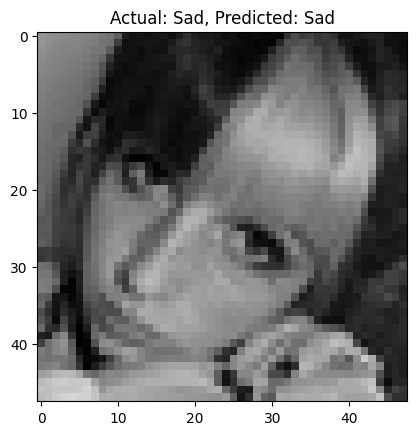

In [39]:

###########################
## Test on train data
cnn_classifier.eval()
# Define class names
class_names = ["Fear", "Happy", "Sad"]  # Add or modify as needed based on your classes
# Get a random index from the test set
random_index = random.randint(0, len(train_dataset) - 1)
# Get the image and label at the random index
image, label = train_dataset[random_index]
image = image.to(device)
label = label.to(device)

output = cnn_classifier(image.unsqueeze(0))  # Unsqueeze to add batch dimension

# Apply threshold for multiclass classification
_, predicted_label = torch.max(output, 1)

# Convert labels to class names
actual_class = class_names[int(label)]
predicted_class = class_names[int(predicted_label)]

# Check if the prediction is correct
is_correct = predicted_label == int(label)

# Print results
print(f"Actual Class: {actual_class}, Predicted Class: {predicted_class}, Correct: {is_correct}")

# Display the image
image = image.cpu().permute(1, 2, 0).numpy()  # Convert to numpy and rearrange dimensions
plt.imshow(image)
plt.title(f"Actual: {actual_class}, Predicted: {predicted_class}")
plt.show()




## Test based off random image from test dataset


In [40]:

############
## call eval model
cnn_classifier.eval()

# Define class names
class_names = ["Fear", "Happy" ,"Sad"]  # Add or modify as needed

# Get a random index from the test set
random_index = random.randint(0, len(test_dataset) - 1)

# Get the image and label at the random index
image, label = test_dataset[random_index]
image = image.to(device)
label = label.to(device)



Actual Class: Happy, Predicted Class: Happy, Correct: tensor([True], device='cuda:0')


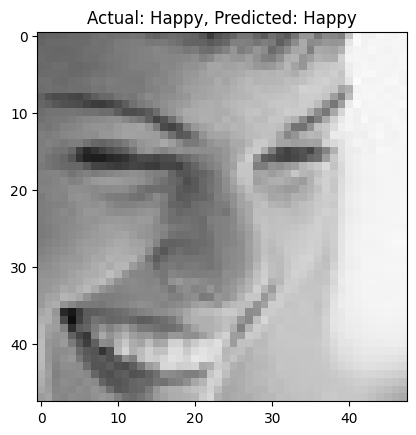

In [41]:

output = cnn_classifier(image.unsqueeze(0))  # Unsqueeze to add batch dimension

# Apply threshold for multiclass classification
_, predicted_label = torch.max(output, 1)

# Convert labels to class names
actual_class = class_names[int(label)]
predicted_class = class_names[int(predicted_label)]

# Check if the prediction is correct
is_correct = predicted_label == int(label)

# Print results
print(f"Actual Class: {actual_class}, Predicted Class: {predicted_class}, Correct: {is_correct}")

# Display the image
image = image.cpu().permute(1, 2, 0).numpy()  # Convert to numpy and rearrange dimensions
plt.imshow(image)
plt.title(f"Actual: {actual_class}, Predicted: {predicted_class}")
plt.show()



In [21]:
import torch.onnx
import torchvision.models as models

# Example: Load a pre-trained ResNet model
cnn_classifier  = models.resnet18(pretrained=True)


dummy_input = torch.randn(1, 3, 48, 48)

# Export the model to ONNX format
onnx_path = "emotion_recognition_model.onnx"
torch.onnx.export(cnn_classifier, dummy_input, onnx_path, verbose=True, input_names=['input'], output_names=['output'])


C:\Users\lenny\anaconda3\envs\kuda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\lenny\anaconda3\envs\kuda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
